正在加载数据...
原始数据行数: 344
处理缺失值后行数: 342

模型评估结果
Accuracy (准确率): 1.0000

Classification Report (分类报告):
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



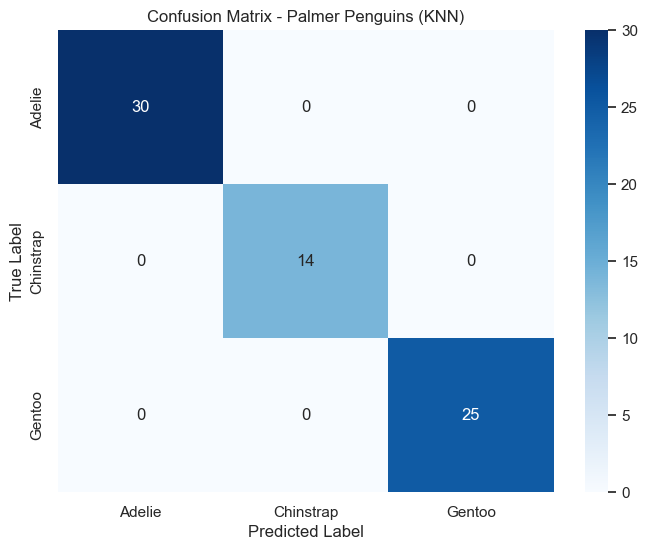

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix #导入accuracy_score, classification_report, confusion_matrix分别为准确率、分类报告和混淆矩阵

# 设置绘图风格
sns.set(style="whitegrid")

# ==========================================    
# 1. 加载数据与特征筛选 (已修正列名)
# ==========================================
print("正在加载数据...")
df = sns.load_dataset('penguins')

# 修正点：将 culmen 替换为 bill
selected_columns = ['species', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
df = df[selected_columns]

# ==========================================
# 2. 处理缺失值
# ==========================================
print(f"原始数据行数: {len(df)}")
# 策略：删除缺失值
df = df.dropna()
print(f"处理缺失值后行数: {len(df)}")

# ==========================================
# 3. 划分训练集与测试集
# ==========================================
X = df.drop('species', axis=1)
y = df['species']

# stratify=y 保证训练集测试集类别比例一致
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ==========================================
# 4. 特征标准化 (StandardScaler)
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 5. 建立 KNN 模型与预测
# ==========================================
# k=5，距离权重默认 uniform
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# ==========================================
# 评估与可视化
# ==========================================
print("\n" + "="*30)
print("模型评估结果")
print("="*30)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (准确率): {acc:.4f}\n")

# Classification Report
print("Classification Report (分类报告):")
print(classification_report(y_test, y_pred))

# 混淆矩阵可视化
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Palmer Penguins (KNN)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

""" 
在分类任务中，仅看 Accuracy（准确率）通常是不够的，原因如下：
1. 样本不平衡（Class Imbalance）问题如果数据集中某一种企鹅的数量远远多于其他种类（例如：Adelie 有 90只，Chinstrap 只有 5只），
模型只要全部预测为 Adelie，准确率依然会高达 90% 以上，但模型实际上并没有学会识别 Chinstrap。Accuracy 掩盖了模型对少数类别的识别缺陷。
F1-score 是 Precision（精确率）和 Recall（召回率）的调和平均数。如果模型忽略了少数类，Recall 会很低，进而导致 F1-score 大幅下降。因此，F1-score 能更真实地反映模型在所有类别上的综合性能。
2. 错误类型的代价不同Precision (精确率) 关注的是“预测为正样本中，有多少是真的”。Recall (召回率) 关注的是“真实的正样本中，有多少被找出来了”。
在某些场景下（例如疾病诊断），漏诊（低 Recall）比误诊（低 Precision）后果更严重。单纯的 Accuracy 无法体现这种权衡，而 F1-score（或者加权的score）结合了两者，提供了更全面的评估视角。
 """

In [ ]:
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import warnings

# 忽略一些不必要的警告
warnings.filterwarnings('ignore')

# ==========================================
# 0. 配置区域 (请修改这里)
# ==========================================
STUDENT_ID = "2328124151"  # <--- 请替换为你的学号
EXPERIMENT_NAME = f"California-Housing-2025-{STUDENT_ID}" #实验名字
MODEL_REGISTRY_NAME = f"CalHousing-KNN-{STUDENT_ID}" #模型注册名字

print(f"正在准备实验: {EXPERIMENT_NAME}")

# ==========================================
# 1. 数据准备
# ==========================================
# 加载数据
data = fetch_california_housing(as_frame=True) #加载加州房价数据集
print(data.head())
X = data.data #获取
y = data.target

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 数据标准化 (KNN 对数据尺度非常敏感，必须缩放)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. 定义超参数搜索空间 (网格搜索)
# ==========================================
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1: 曼哈顿距离, 2: 欧氏距离
}
# 生成所有参数组合
grid = list(ParameterGrid(param_grid))

# ==========================================
# 3. MLflow 实验设置与运行
# ==========================================

# 设置实验名称
mlflow.set_experiment(EXPERIMENT_NAME)

best_rmse = float('inf') #嘴还的RMSE
best_run_id = None

# 开启一个父运行 (Parent Run)，方便在 UI 中折叠管理
print("开始网格搜索...")
with mlflow.start_run(run_name="Grid_Search_Parent") as parent_run:
    
    for i, params in enumerate(grid):
        # (1) 用 nested=True 包裹每次训练
        with mlflow.start_run(nested=True, run_name=f"Trial_{i}") as run:
            
            # 训练模型
            knn = KNeighborsRegressor(**params)
            knn.fit(X_train_scaled, y_train)
            
            # 预测
            y_pred = knn.predict(X_test_scaled)
            
            # 计算指标
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            
            # (2) 记录内容
            # 记录参数
            mlflow.log_params(params)
            
            # 记录指标
            mlflow.log_metric("test_rmse", rmse)
            
            # 记录标签
            mlflow.set_tag("student_id", STUDENT_ID)
            
            # 记录模型 (方便后续注册)
            mlflow.sklearn.log_model(knn, "model")
            
            print(f"Run {i}: Params={params}, RMSE={rmse:.4f}")
            
            # 记录最佳结果
            if rmse < best_rmse:
                best_rmse = rmse
                best_run_id = run.info.run_id

print("-" * 30)
print(f"搜索结束。最佳 RMSE: {best_rmse:.4f}")
print(f"最佳 Run ID: {best_run_id}")

# ==========================================
# 4. 模型注册与别名设置
# ==========================================

if best_run_id:
    print(f"正在注册模型到: {MODEL_REGISTRY_NAME}...")
    
    # 构建模型 URI
    model_uri = f"runs:/{best_run_id}/model"
    
    # (3) 注册模型
    registered_model = mlflow.register_model(model_uri, MODEL_REGISTRY_NAME)
    
    # 获取版本号 (register_model 返回的是对象，我们取其 version)
    version = registered_model.version
    
    print(f"模型已注册，版本号: {version}")
    
    # (3.2) 设置别名 bestknn
    client = MlflowClient()
    client.set_registered_model_alias(
        name=MODEL_REGISTRY_NAME,
        alias="bestknn",
        version=version
    )
    
    print(f"成功为模型 {MODEL_REGISTRY_NAME} 版本 {version} 设置别名 'bestknn'")
    print("\n所有任务完成！请在终端运行 'mlflow ui' 查看结果。")

else:
    print("未找到有效运行结果，无法注册模型。")

2025/12/04 14:58:23 INFO mlflow.tracking.fluent: Experiment with name 'California-Housing-2025-2328124151' does not exist. Creating a new experiment.


正在准备实验: California-Housing-2025-2328124151
开始网格搜索...


2025/12/04 14:58:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/04 14:58:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/12/04 14:58:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 0: Params={'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}, RMSE=0.6452


2025/12/04 14:58:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/12/04 14:58:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

2025/12/04 14:59:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/04 14:59:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run 14: Params={'n_neighbors': 9, 'p': 2, 'weights': 'uniform'}, RMSE=0.6516


2025/12/04 14:59:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/04 14:59:25 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Successfully registered model 'CalHousing-KNN-2328124151'.
2025/12/04 14:59:25 WARNING mlflow.tracking._model_registry.fluent: Run with id f4f794036bbf486d850a771c3bacb301 has no artifacts at artifact path 'model', registering model based on models:/m-49650ae41e774cc8827348ffe1645a78 instead


Run 15: Params={'n_neighbors': 9, 'p': 2, 'weights': 'distance'}, RMSE=0.6474
------------------------------
搜索结束。最佳 RMSE: 0.6034
最佳 Run ID: f4f794036bbf486d850a771c3bacb301
正在注册模型到: CalHousing-KNN-2328124151...
模型已注册，版本号: 1
成功为模型 CalHousing-KNN-2328124151 版本 1 设置别名 'bestknn'

所有任务完成！请在终端运行 'mlflow ui' 查看结果。


Created version '1' of model 'CalHousing-KNN-2328124151'.
